In [2]:
import numpy as np
import matplotlib.pyplot as plt     

In [3]:
%%bash
cd ..
g++ -std=c++17 -Wall Curve.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o Curvilinear

        

SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:505:26: warning: unused variable ‘tol’ [-Wunused-variable]
  505 |             const double tol = 1e-14;
      |                          ^~~
SRC/Simulation.cpp: In member function ‘void Simulation::write_Cd(const string&)’:
SRC/Simulation.cpp:68:12: warning: unused variable ‘Cd’ [-Wunused-variable]
   68 |     double Cd = 0.0;
      |            ^~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:220:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  220 |     double gamma = 1.4;
      |            ^~~~~
SRC/Solver.cpp: At global scope:
SRC/Solver.cpp:179:15: warning: ‘double total_velocity(double, double, double, double)’ defined but not used [-Wunused-function]
  179 | static double total_velocity(double gamma, double M, double R, double T) {
      |               ^~~~~~~~~~~~~~
SRC/Solver.cpp:168:

In [4]:
# %%bash
# cd ..
# ./Curvilinear

In [5]:
pi = 3.14159265358979323846 #explicitly if you want exact match

rho0   = 1.0
rhox   = 0.15
rhoy   = -0.1

uvel0  = 800.0
uvelx  = 50.0
uvely  = -30.0

vvel0  = 800.0
vvelx  = -75.0
vvely  = 40.0

press0 = 100000.0
pressx = 20000.0
pressy = 50000.0

def load_grid(filename):

    with open(filename, 'r') as f:
        # Read integers
        nzones = int(f.readline())
        imax, jmax, kmax = map(int, f.readline().split())

        size = imax * jmax * kmax

        # Read the flattened data for x, y, and zztemp
        data = []
        while len(data) < 3 * size:
            line = f.readline()
            data.extend(map(float, line.split()))

        # Split data into x, y, zztemp
        data = np.array(data)
        x = data[0:size].reshape((kmax, jmax, imax))
        y = data[size:2*size].reshape((kmax, jmax, imax))
        zztemp = data[2*size:].reshape((kmax, jmax, imax))

    return x[0],y[0]


def rho_mms(length, x, y):
    return rho0 + rhoy * np.cos((np.pi * y) / (2.0 * length)) + rhox * np.sin((np.pi * x) / length)

def uvel_mms(length, x, y):
    return uvel0 + uvely * np.cos((3.0 * np.pi * y) / (5.0 * length)) + uvelx * np.sin((3.0 * np.pi * x) / (2.0 * length))

def vvel_mms(length, x, y):
    return vvel0 + vvelx * np.cos((np.pi * x) / (2.0 * length)) + vvely * np.sin((2.0 * np.pi * y) / (3.0 * length))

def press_mms(length, x, y):
    return press0 + pressx * np.cos((2.0 * np.pi * x) / length) + pressy * np.sin((np.pi * y) / length)

def compute_order(errors):
    """Compute order of convergence given a list of errors."""
    return [np.log(errors[i] / errors[i+1]) / np.log(2) for i in range(len(errors) - 1)]

In [6]:

X = np.linspace(0,1,32*2+1)
Y = np.linspace(0,1,32*2+1)

x,y  = np.meshgrid(X,Y)

x11 = x[0:-1,0:-1]
x12 = x[0:-1,1:]
x21 = x[1:,0:-1]
x22 = x[1:,1:]

y11 = y[0:-1,0:-1]
y12 = y[0:-1,1:]
y21 = y[1:,0:-1]
y22 = y[1:,1:]

x_cells= np.array([x21,x22,x11,x12])
y_cells = np.array([y21,y22,y11,y12])
x_cells = x_cells.reshape((4,x11.shape[0]*x11.shape[1]))
y_cells = y_cells.reshape((4,x11.shape[0]*x11.shape[1]))


In [7]:
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Curvilinear/curv2d129.grd")
x_midpoint = (x[1:,1:]+x[0:-1,0:-1]+x[1:,0:-1]+x[0:-1,1:])/4
y_midpoint = (y[1:,1:]+y[0:-1,0:-1]+y[1:,0:-1]+y[0:-1,1:])/4
data = np.loadtxt("../primitives.csv", delimiter=",")
NI =32*2*2
NJ = 32*2*2

print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(5, 16384)


In [8]:
# p = p.reshape((NI,NJ))

# p_err = (p-press_mms(1,x_midpoint,y_midpoint))  # shape (NI, NJ)
# rho_err = (rho-rho_mms(1,x_midpoint,y_midpoint))
# uvel_err = u - uvel_mms(1,x_midpoint,y_midpoint)
# vvel_err = v-vvel_mms(1,x_midpoint,y_midpoint)

# L1  = np.mean(np.abs(err))                  # (1/N) * sum |e|
# L2  = np.sqrt(np.mean(err**2))              # sqrt( (1/N) * sum e^2 )
# Linf = np.max(np.abs(err))
# plt.imshow(err)
# plt.colorbar()
# print(L1,L2,Linf)

In [9]:
p.shape

(128, 128)

=== Primitive variable errors ===
rho        | L1 = 5.134855e-03, L2 = 6.629055e-03, Linf = 2.020369e-02
u          | L1 = 9.914682e-01, L2 = 1.172991e+00, Linf = 2.299713e+00
v          | L1 = 2.805719e-01, L2 = 3.544745e-01, Linf = 1.029517e+00
p          | L1 = 4.592823e+02, L2 = 6.533539e+02, Linf = 1.840148e+03

=== Conserved variable errors ===
rho        | L1 = 5.134855e-03, L2 = 6.629055e-03, Linf = 2.020369e-02
rhou       | L1 = 4.456670e+00, L2 = 5.674114e+00, Linf = 1.655153e+01
rhov       | L1 = 3.814304e+00, L2 = 5.005662e+00, Linf = 1.640293e+01
rhoE       | L1 = 4.413290e+03, L2 = 5.648076e+03, Linf = 1.537259e+04


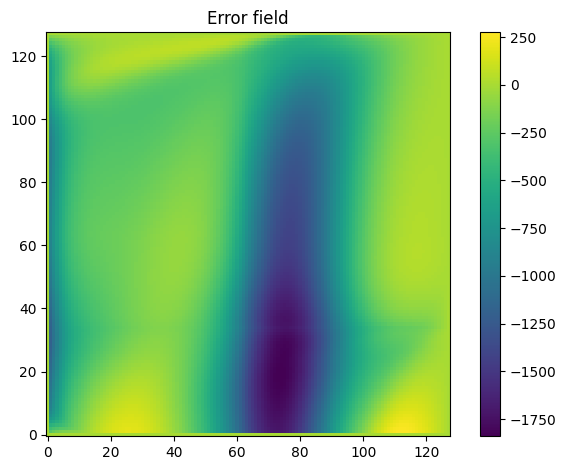

In [10]:
import numpy as np
import matplotlib.pyplot as plt
gamma = 1.4
# --- helpers ---------------------------------------------------------------

def primitives_to_conserved(rho, u, v, p, gamma, eps=0.0):
    """
    Convert primitive variables to conserved:
      U = [ rho, rho*u, rho*v, rho*E ]
    where E = p/[(gamma-1) * rho] + 0.5*(u^2+v^2)
    eps: optional density floor (set >0 to avoid division issues).
    """
    rho_safe = np.maximum(rho, eps) if eps > 0 else rho
    kinetic = 0.5 * (u**2 + v**2)
    e_int   = p / ((gamma - 1.0) * rho_safe)
    E       = e_int + kinetic
    return rho, rho*u, rho*v, rho*E

def error_norms(err):
    """Return (L1, L2, Linf) for an error array."""
    e = np.asarray(err)
    L1   = np.mean(np.abs(e))
    L2   = np.sqrt(np.mean(e**2))
    Linf = np.max(np.abs(e))
    return L1, L2, Linf

def summarize_norms(name, err):
    L1, L2, Linf = error_norms(err)
    return f"{name:<10} | L1 = {L1:.6e}, L2 = {L2:.6e}, Linf = {Linf:.6e}"

# --- MMS ground truth (primitives) ----------------------------------------

t_eval = 1  # <-- match your existing call signature
rho_ref = rho_mms(t_eval, x_midpoint, y_midpoint)
u_ref   = uvel_mms(t_eval, x_midpoint, y_midpoint)
v_ref   = vvel_mms(t_eval, x_midpoint, y_midpoint)
p_ref   = press_mms(t_eval, x_midpoint, y_midpoint)

# --- primitive errors ------------------------------------------------------

rho_err = rho - rho_ref
u_err   = u   - u_ref
v_err   = v   - v_ref
p_err   = p   - p_ref

# --- convert both numerical and MMS primitives -> conserved ----------------

rho_c, rhou_c, rhov_c, rhoE_c = primitives_to_conserved(rho,    u,    v,    p,    gamma)
rho_r, rhou_r, rhov_r, rhoE_r = primitives_to_conserved(rho_ref,u_ref,v_ref,p_ref,gamma)

# --- conserved errors ------------------------------------------------------

rho_cons_err  = rho_c  - rho_r
rhou_cons_err = rhou_c - rhou_r
rhov_cons_err = rhov_c - rhov_r
rhoE_cons_err = rhoE_c - rhoE_r

# --- print clean summaries -------------------------------------------------

lines = []
lines.append("=== Primitive variable errors ===")
lines.append(summarize_norms("rho", rho_err))
lines.append(summarize_norms("u",   u_err))
lines.append(summarize_norms("v",   v_err))
lines.append(summarize_norms("p",   p_err))
lines.append("")
lines.append("=== Conserved variable errors ===")
lines.append(summarize_norms("rho",  rho_cons_err))
lines.append(summarize_norms("rhou", rhou_cons_err))
lines.append(summarize_norms("rhov", rhov_cons_err))
lines.append(summarize_norms("rhoE", rhoE_cons_err))

print("\n".join(lines))

# --- optional: quick look at an error field as a heatmap -------------------
# choose any error to visualize (e.g., pressure error)
err_to_show = p_err  # change to rho_cons_err, rhou_cons_err, etc.

plt.figure()
plt.imshow(err_to_show, origin="lower")
plt.title("Error field")
plt.colorbar()
plt.tight_layout()
plt.show()


In [11]:

## VAN LEER

cons = [
    # SuperCoarse
    [
        [1.051413e-02, 1.569357e-02, 4.904523e-02],  # rho
        [1.310470e+01, 1.749289e+01, 4.280648e+01],  # rhou
        [7.539930e+00, 1.152766e+01, 3.681903e+01],  # rhov
        [1.232709e+04, 1.709933e+04, 4.139593e+04],  # rhoE
    ],
    # COARSE
    [
        [6.606896e-03, 9.967189e-03, 3.400996e-02],  # rho
        [7.884709e+00, 1.039585e+01, 2.699398e+01],  # rhou
        [4.770992e+00, 7.391793e+00, 2.598586e+01],  # rhov
        [7.166916e+03, 9.684961e+03, 2.781450e+04],  # rhoE
    ],
    # MEDIUM
    [
        [3.904771e-03, 5.860401e-03, 2.093448e-02],  # rho
        [4.296368e+00, 5.756184e+00, 1.589755e+01],  # rhou
        [2.856745e+00, 4.380691e+00, 1.619563e+01],  # rhov
        [3.833332e+03, 5.284375e+03, 1.716166e+04],  # rhoE
    ],
    # FINE
    [
        [2.165142e-03, 3.246383e-03, 1.206975e-02],  # rho
        [2.247413e+00, 3.059841e+00, 8.890718e+00],  # rhou
        [1.602478e+00, 2.440896e+00, 9.350029e+00],  # rhov
        [1.975862e+03, 2.802877e+03, 9.825752e+03],  # rhoE
    ],
]


In [12]:
## ROES METHOD 



cons = [
    # Supercoarse
    [
        [2.327387e-02, 3.226782e-02, 9.052032e-02],  # rho
        [1.976341e+01, 2.676729e+01, 6.883009e+01],  # rhou
        [1.716547e+01, 2.417451e+01, 6.902933e+01],  # rhov
        [2.202173e+04, 3.048463e+04, 8.467873e+04],  # rhoE
    ],
    # Coarse
    [
        [1.597115e-02, 2.116718e-02, 5.324290e-02],  # rho
        [1.374427e+01, 1.793682e+01, 4.110394e+01],  # rhou
        [1.183761e+01, 1.590232e+01, 4.084718e+01],  # rhov
        [1.436913e+04, 1.895034e+04, 4.816202e+04],  # rhoE
    ],
    # Medium
    [
        [9.421195e-03, 1.225352e-02, 3.244201e-02],  # rho
        [8.158327e+00, 1.046163e+01, 2.724163e+01],  # rhou
        [6.993774e+00, 9.232702e+00, 2.615490e+01],  # rhov
        [8.227610e+03, 1.062311e+04, 2.563826e+04],  # rhoE
    ],
    # FINE
    [
        [5.134855e-03, 6.629055e-03, 2.020369e-02],  # rho
        [4.456670e+00, 5.674114e+00, 1.655153e+01],  # rhou
        [3.814304e+00, 5.005662e+00, 1.640293e+01],  # rhov
        [4.413290e+03, 5.648076e+03, 1.537259e+04],  # rhoE
    ],
]


In [13]:
cons = np.array(cons)
mass_L1 = cons[:,0,0]
mass_L2 = cons[:,0,1]
mass_Linf = cons[:,0,2]

# x-momentum (rhou)
momentum_x_L1   = cons[:,1,0]
momentum_x_L2   = cons[:,1,1]
momentum_x_Linf = cons[:,1,2]

# y-momentum (rhov)
momentum_y_L1   = cons[:,2,0]
momentum_y_L2   = cons[:,2,1]
momentum_y_Linf = cons[:,2,2]

# total energy (rhoE)
energy_L1   = cons[:,3,0]
energy_L2   = cons[:,3,1]
energy_Linf = cons[:,3,2]


In [14]:
mass_L1 = compute_order(cons[:,0,0])[::-1]
mass_L2 = compute_order(cons[:,0,1])[::-1]
mass_Linf = compute_order(cons[:,0,2])[::-1]

# x-momentum (rhou)
momentum_x_L1   = compute_order(cons[:,1,0])[::-1]
momentum_x_L2   = compute_order(cons[:,1,1])[::-1]
momentum_x_Linf = compute_order(cons[:,1,2])[::-1]

# y-momentum (rhov)
momentum_y_L1   = compute_order(cons[:,2,0])[::-1]
momentum_y_L2   = compute_order(cons[:,2,1])[::-1]
momentum_y_Linf = compute_order(cons[:,2,2])[::-1]

# total energy (rhoE)
energy_L1   = compute_order(cons[:,3,0])[::-1]
energy_L2   = compute_order(cons[:,3,1])[::-1]
energy_Linf = compute_order(cons[:,3,2])[::-1]


In [15]:
compute_order(momentum_x_L1)

[0.2131733824836265, 0.522091664227425]

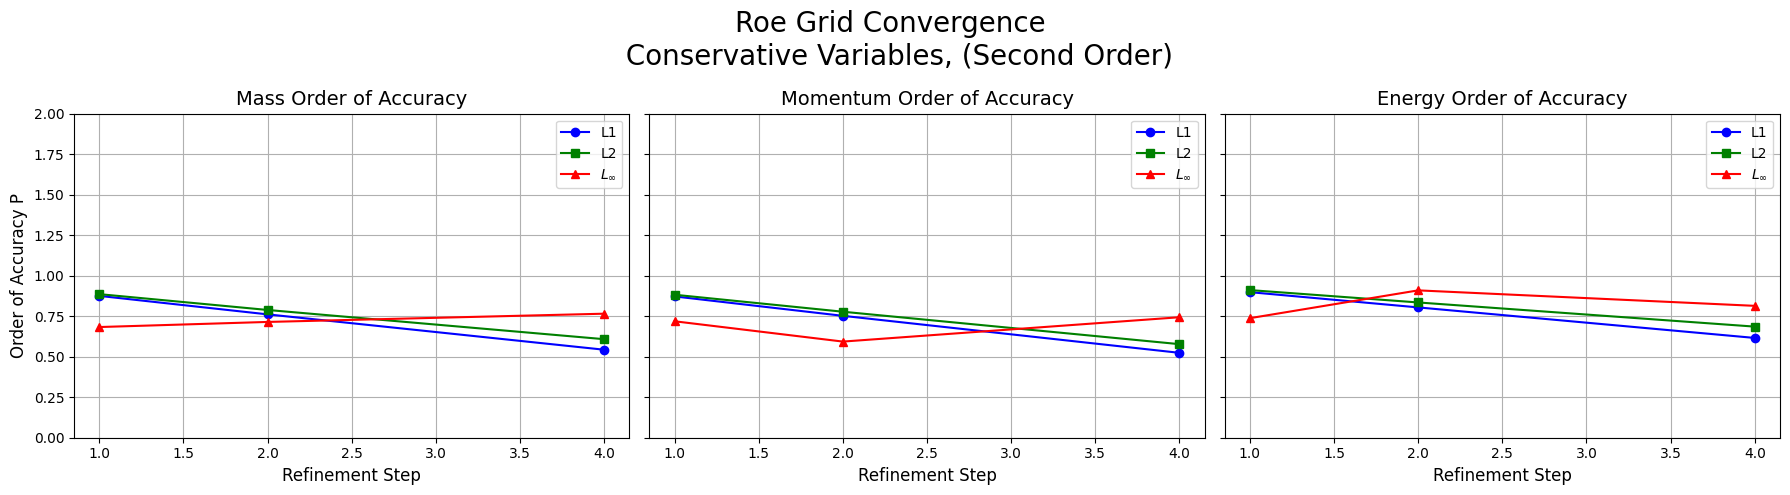

In [16]:

x_values = [1, 2, 4]  # refinement steps (e.g., h ratios)


fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- Mass ---
axs[0].plot(x_values, mass_L1, 'o-', label='L1', color='b')
axs[0].plot(x_values, mass_L2, 's-', label='L2', color='g')
axs[0].plot(x_values, mass_Linf, '^-', label=r"$L_\infty$", color='r')
axs[0].set_title("Mass Order of Accuracy", fontsize=14)
axs[0].set_xlabel("Refinement Step", fontsize=12)
axs[0].set_ylabel("Order of Accuracy P", fontsize=12)
axs[0].set_ylim([0, 2])
axs[0].grid(True)
axs[0].legend()

# --- Momentum ---
axs[1].plot(x_values, momentum_x_L1, 'o-', label='L1', color='b')
axs[1].plot(x_values, momentum_x_L2, 's-', label='L2', color='g')
axs[1].plot(x_values, momentum_x_Linf, '^-', label=r"$L_\infty$", color='r')
axs[1].set_title("Momentum Order of Accuracy", fontsize=14)
axs[1].set_xlabel("Refinement Step", fontsize=12)
axs[1].set_ylim([0, 2])
axs[1].grid(True)
axs[1].legend()

# --- Energy ---
axs[2].plot(x_values, energy_L1, 'o-', label='L1', color='b')
axs[2].plot(x_values, energy_L2, 's-', label='L2', color='g')
axs[2].plot(x_values, energy_Linf, '^-', label=r"$L_\infty$", color='r')
axs[2].set_title("Energy Order of Accuracy", fontsize=14)
axs[2].set_xlabel("Refinement Step", fontsize=12)
axs[2].set_ylim([0, 2])
axs[2].grid(True)
axs[2].legend()
plt.suptitle("Roe Grid Convergence \n Conservative Variables, (Second Order)",fontsize=20)
plt.tight_layout()
plt.savefig("Roe_Order2")


In [17]:
plt.imshow(err)
plt.colorbar()

NameError: name 'err' is not defined

In [ ]:

def triangle_area_2d(a, b, c):
    u = np.array(b) - np.array(a)
    v = np.array(c) - np.array(a)
    return 0.5 * abs(u[0]*v[1] - u[1]*v[0])
xx = x; yy = y;
p1 = [xx[0:-1,0:-1],yy[0:-1,0:-1]]
p2 = [xx[1:,0:-1],yy[1:,0:-1]] 
p3 = [xx[0:-1,1:],yy[0:-1,1:]] 
p4 = [xx[1:,1:],yy[1:,1:]]
areas = triangle_area_2d(p1,p2,p3 ) + triangle_area_2d(p1, p3, p4)

plt.imshow(areas)

In [ ]:
import numpy as np

In [ ]:
#X = np.linspace(0,1,41)
#Y = np.linspace(0,1,41)

#x,y  = np.meshgrid(X,Y)
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.extra-coarse.27x14.grd")
x11 = x[0:-1,0:-1]
x12 = x[0:-1,1:]
x21 = x[1:,0:-1]
x22 = x[1:,1:]

y11 = y[0:-1,0:-1]
y12 = y[0:-1,1:]
y21 = y[1:,0:-1]
y22 = y[1:,1:]

x_cells= np.array([x21,x22,x11,x12])
y_cells = np.array([y21,y22,y11,y12])
x_cells = x_cells.reshape((4,x11.shape[0]*x11.shape[1]))
y_cells = y_cells.reshape((4,x11.shape[0]*x11.shape[1]))

# np.savetxt(f"/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/Airfoil_Supercoarse_cells_xx.csv",(x_cells.T).copy(),delimiter=",")
# np.savetxt(f"/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/Airfoil_Supercoarse_cells_yy.csv",(y_cells.T).copy(),delimiter=",")


In [ ]:
import MMS_functions
from ctypes import c_double

In [ ]:
MMS_functions.set_inputs.initialize_constants()


In [ ]:
mass_test = np.vectorize(MMS_functions.rmassconv,otypes=[c_double])
ymtm_test = np.vectorize(MMS_functions.ymtmconv,otypes=[c_double])
xmtm_test = np.vectorize(MMS_functions.xmtmconv,otypes=[c_double])
E_test = np.vectorize(MMS_functions.energyconv,otypes=[c_double])
rho_test = np.vectorize(MMS_functions.rho_mms)
rho_ = rho_test(np.array(1.0).astype(c_double),x_midpoint.astype(c_double),y_midpoint.astype(c_double))

mass_ = mass_test(np.array(1000.0).astype(c_double),x_midpoint.astype(c_double),y_midpoint.astype(c_double))
y_ = ymtm_test(np.array(1.0).astype(c_double),x_midpoint.astype(c_double),y_midpoint.astype(c_double))
x_ = xmtm_test(np.array(1.0).astype(c_double),x_midpoint.astype(c_double),y_midpoint.astype(c_double))
E = E_test(1.4,np.array(1.0).astype(c_double),x_midpoint.astype(c_double),y_midpoint.astype(c_double))

In [ ]:
plt.imshow(mass_)
plt.colorbar()